# Prediksi AI pada Sistem IoT Monitoring Kandang Telur

Notebook ini menjelaskan alur data science / machine learning pada project IoT monitoring kandang telur.

Model yang dipakai di sistem web:
- **XGBoost Regressor** untuk prediksi jumlah telur
- **Random Forest Classifier** untuk status `Produktif`, `Perlu Dipantau`, `Afkir`
- **Isolation Forest** untuk deteksi anomali


## 1. Business Understanding

Tujuan project:
1. Memprediksi jumlah telur per sensor.
2. Menentukan status produktivitas sensor / ayam.
3. Mendeteksi anomali dari pola suhu, kelembapan, dan gas.
4. Menampilkan hasil AI ke dashboard web agar user tidak hanya melihat data mentah.


## 2. Data Understanding

Sumber data utama dari project:
- `EggEvent`
- `SensorReading`
- `GasReading`
- `SensorAiPrediction`

Pada tahap eksperimen ini, dataset dibentuk dari histori dummy yang sudah dirapikan dari **1 Januari 2026 sampai 2 Mei 2026**.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

DATASET_CANDIDATES = [
    Path('/opt/egg-monitoring-web/artifacts/ai-dataset.json'),
    Path('/home/nashiru/egg-monitoring-work/artifacts/ai-dataset.json'),
    Path('/tmp/egg-ai-dataset.json'),
]

PREDICTION_CANDIDATES = [
    Path('/opt/egg-monitoring-web/artifacts/ai-predictions.json'),
    Path('/home/nashiru/egg-monitoring-work/artifacts/ai-predictions.json'),
    Path('/tmp/egg-ai-predictions.json'),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(f'Tidak menemukan file dari kandidat: {paths}')

dataset_path = first_existing(DATASET_CANDIDATES)
prediction_path = first_existing(PREDICTION_CANDIDATES)

print('Dataset path :', dataset_path)
print('Prediction path:', prediction_path)


Dataset path : /tmp/egg-ai-dataset.json
Prediction path: /tmp/egg-ai-predictions.json


In [2]:
with open(dataset_path, 'r', encoding='utf-8') as f:
    dataset_payload = json.load(f)

with open(prediction_path, 'r', encoding='utf-8') as f:
    prediction_payload = json.load(f)

print('Date range  :', dataset_payload.get('dateRange'))
print('All months  :', dataset_payload.get('months'))
print('Full months :', dataset_payload.get('fullMonths'))
print('Train rows  :', len(dataset_payload.get('trainRows', [])))
print('Pred rows   :', len(dataset_payload.get('predictionRows', [])))
print('Metrics     :', prediction_payload.get('metrics'))


Date range  : {'start': '2026-01-01T00:00:00.000Z', 'end': '2026-05-02T23:59:59.999Z'}
All months  : ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Full months : ['2026-01', '2026-02', '2026-03', '2026-04']
Train rows  : 12
Pred rows   : 4
Metrics     : {'regression_mae': 0.652, 'classification_accuracy': 0.667, 'test_rows': 3}


In [3]:
train_df = pd.DataFrame([
    {
        'deviceId': row['deviceId'],
        'sensorId': row['sensorId'],
        'sourceMonth': row['sourceMonth'],
        'targetMonth': row['targetMonth'],
        **row['features'],
        'targetMonthlyEggs': row['target']['monthlyEggs'],
        'targetStatus': row['target']['status'],
    }
    for row in dataset_payload['trainRows']
])

prediction_df = pd.DataFrame([
    {
        'deviceId': row['deviceId'],
        'sensorId': row['sensorId'],
        'sourceMonth': row['sourceMonth'],
        'targetMonth': row['targetMonth'],
        **row['features'],
    }
    for row in dataset_payload['predictionRows']
])

result_df = pd.DataFrame(prediction_payload['predictions'])

train_df.head()


,deviceId,sensorId,sourceMonth,targetMonth,sensorIndex,prevMonthlyEggs,prevEggs7d,daysWithoutEgg,avgTemp30d,avgHumidity30d,gasAlertCount30d,gasAlertCount7d,rollingEggAvg2m,targetMonthlyEggs,targetStatus
0,esp32-01,A001,2026-01,2026-02,0,26,6,0,28.40,54.54,27,7,13.0,25,Produktif
1,esp32-01,A002,2026-01,2026-02,1,22,6,0,28.40,54.54,27,7,11.0,21,Perlu Dipantau
2,esp32-01,B001,2026-01,2026-02,2,16,4,0,28.40,54.54,27,7,8.0,16,Afkir
3,esp32-01,B002,2026-01,2026-02,3,11,3,0,28.40,54.54,27,7,5.5,10,Afkir
4,esp32-01,A001,2026-02,2026-03,0,25,6,0,28.42,54.79,27,10,12.5,24,Produktif


### Ringkasan Data Training

Di sini terlihat bahwa setiap baris mewakili **1 sensor pada 1 bulan sumber**, lalu targetnya adalah **bulan berikutnya**.


In [4]:
train_df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
deviceId,12,1,esp32-01,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensorId,12,4,A001,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sourceMonth,12,3,2026-01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
targetMonth,12,3,2026-02,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensorIndex,12.0,NaN,NaN,NaN,1.5,1.167748,0.0,0.75,1.5,2.25,3.0
prevMonthlyEggs,12.0,NaN,NaN,NaN,17.916667,5.946096,9.0,14.0,18.0,22.5,26.0
prevEggs7d,12.0,NaN,NaN,NaN,4.333333,1.370689,2.0,3.0,4.5,5.25,6.0
daysWithoutEgg,12.0,NaN,NaN,NaN,0.083333,0.288675,0.0,0.0,0.0,0.0,1.0
avgTemp30d,12.0,NaN,NaN,NaN,28.423333,0.021462,28.4,28.4,28.42,28.45,28.45
avgHumidity30d,12.0,NaN,NaN,NaN,54.7,0.118475,54.54,54.54,54.77,54.79,54.79


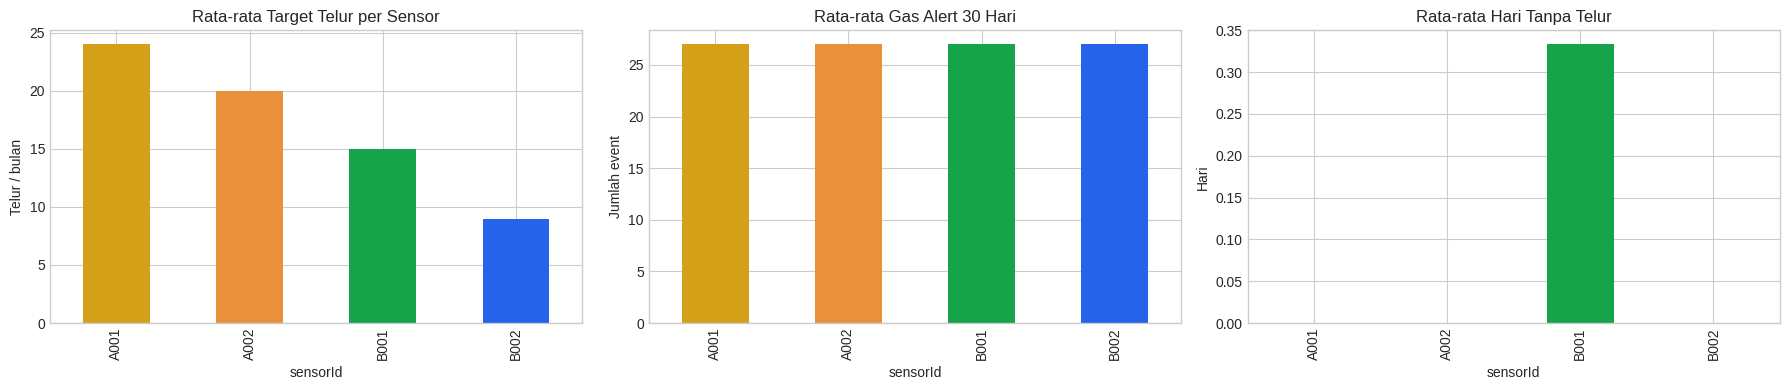

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

train_df.groupby('sensorId')['targetMonthlyEggs'].mean().plot(kind='bar', ax=axes[0], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[0].set_title('Rata-rata Target Telur per Sensor')
axes[0].set_ylabel('Telur / bulan')

train_df.groupby('sensorId')['gasAlertCount30d'].mean().plot(kind='bar', ax=axes[1], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[1].set_title('Rata-rata Gas Alert 30 Hari')
axes[1].set_ylabel('Jumlah event')

train_df.groupby('sensorId')['daysWithoutEgg'].mean().plot(kind='bar', ax=axes[2], color=['#D4A017', '#E8913A', '#16A34A', '#2563EB'])
axes[2].set_title('Rata-rata Hari Tanpa Telur')
axes[2].set_ylabel('Hari')

plt.tight_layout()
plt.show()


## 3. Data Preparation

Tahap preprocessing yang dilakukan pada project ini:
- filter tanggal `2026-01-01` sampai `2026-05-02`
- kelompokkan data per bulan dan per sensor
- bulan yang belum penuh, seperti Mei yang baru 2 hari, **tidak dipakai sebagai target training**
- hasilnya dibagi menjadi:
  - `trainRows`
  - `predictionRows`


In [6]:
print('Bulan penuh untuk training:', dataset_payload['fullMonths'])
print('\nContoh prediction rows:')
prediction_df


Bulan penuh untuk training: ['2026-01', '2026-02', '2026-03', '2026-04']

Contoh prediction rows:


,deviceId,sensorId,sourceMonth,targetMonth,sensorIndex,prevMonthlyEggs,prevEggs7d,daysWithoutEgg,avgTemp30d,avgHumidity30d,gasAlertCount30d,gasAlertCount7d,rollingEggAvg2m
0,esp32-01,A001,2026-04,2026-05,0,23,5,0,28.38,54.6,31,5,24
1,esp32-01,A002,2026-04,2026-05,1,19,5,0,28.38,54.6,31,5,20
2,esp32-01,B001,2026-04,2026-05,2,14,3,1,28.38,54.6,31,5,15
3,esp32-01,B002,2026-04,2026-05,3,8,2,0,28.38,54.6,31,5,9


## 4. Feature Engineering

Fitur yang dipakai model di project ini:
- `sensorIndex`
- `prevMonthlyEggs`
- `prevEggs7d`
- `daysWithoutEgg`
- `avgTemp30d`
- `avgHumidity30d`
- `gasAlertCount30d`
- `gasAlertCount7d`
- `rollingEggAvg2m`


In [7]:
feature_cols = [
    'sensorIndex',
    'prevMonthlyEggs',
    'prevEggs7d',
    'daysWithoutEgg',
    'avgTemp30d',
    'avgHumidity30d',
    'gasAlertCount30d',
    'gasAlertCount7d',
    'rollingEggAvg2m',
]

train_df[feature_cols].corr().round(2)


,sensorIndex,prevMonthlyEggs,prevEggs7d,daysWithoutEgg,avgTemp30d,avgHumidity30d,gasAlertCount30d,gasAlertCount7d,rollingEggAvg2m
sensorIndex,1.00,-0.99,-0.91,0.13,-0.00,-0.00,NaN,-0.00,-0.66
prevMonthlyEggs,-0.99,1.00,0.95,-0.15,-0.13,-0.10,NaN,0.06,0.57
prevEggs7d,-0.91,0.95,1.00,-0.31,-0.32,-0.21,NaN,0.21,0.39
daysWithoutEgg,0.13,-0.15,-0.31,1.00,0.39,0.19,NaN,-0.34,0.18
avgTemp30d,-0.00,-0.13,-0.32,0.39,1.00,0.76,NaN,-0.50,0.65
avgHumidity30d,-0.00,-0.10,-0.21,0.19,0.76,1.00,NaN,0.19,0.29
gasAlertCount30d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasAlertCount7d,-0.00,0.06,0.21,-0.34,-0.50,0.19,NaN,1.00,-0.59
rollingEggAvg2m,-0.66,0.57,0.39,0.18,0.65,0.29,NaN,-0.59,1.00


## 5. Modelling

Model yang digunakan pada sistem produksi:
- `XGBoost Regressor`
- `RandomForestClassifier`
- `IsolationForest`

Notebook ini fokus untuk menjelaskan alur data dan hasil model, bukan menggantikan pipeline produksi di server.


In [8]:
print('Model version:', prediction_payload.get('modelVersion'))
print('Evaluation metrics:', prediction_payload.get('metrics'))


Model version: xgb-rf-iforest-v1
Evaluation metrics: {'regression_mae': 0.652, 'classification_accuracy': 0.667, 'test_rows': 3}


## 6. Evaluation

Evaluasi yang muncul dari pipeline:
- `regression_mae`
- `classification_accuracy`
- `test_rows`


In [9]:
metrics_df = pd.DataFrame([prediction_payload.get('metrics', {})])
metrics_df


,regression_mae,classification_accuracy,test_rows
0,0.652,0.667,3


In [10]:
result_df[['sensorId', 'predictedEggs7d', 'predictedMonthlyEggs', 'predictedStatus', 'confidence', 'afkirRiskScore', 'anomalyLabel']]


,sensorId,predictedEggs7d,predictedMonthlyEggs,predictedStatus,confidence,afkirRiskScore,anomalyLabel
0,A001,5.2,23.0,Perlu Dipantau,0.73,0.36,Tinggi
1,A002,4.4,19.7,Perlu Dipantau,0.72,0.46,Rendah
2,B001,3.4,15.1,Afkir,0.73,0.83,Tinggi
3,B002,2.1,9.5,Afkir,0.95,0.97,Tinggi


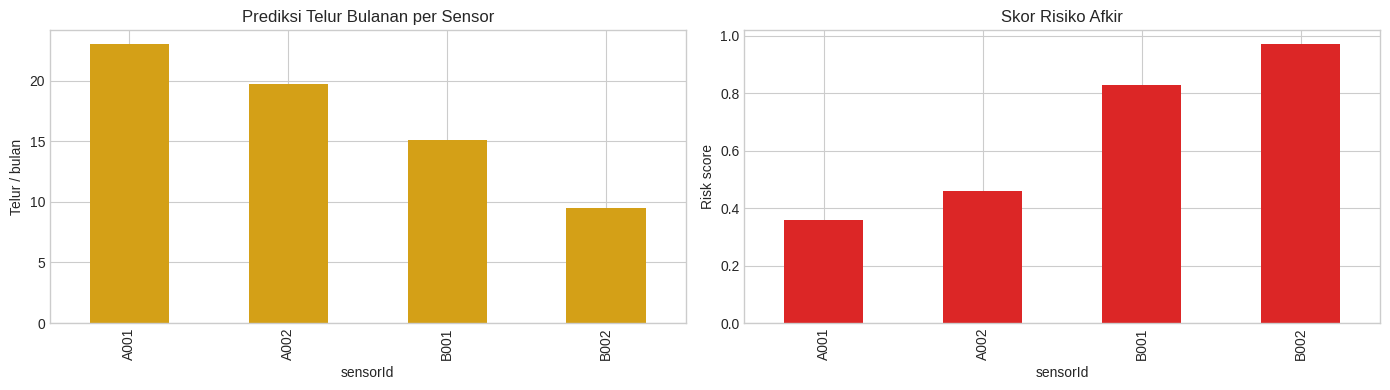

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

result_df.plot(x='sensorId', y='predictedMonthlyEggs', kind='bar', ax=axes[0], legend=False, color='#D4A017')
axes[0].set_title('Prediksi Telur Bulanan per Sensor')
axes[0].set_ylabel('Telur / bulan')

result_df.plot(x='sensorId', y='afkirRiskScore', kind='bar', ax=axes[1], legend=False, color='#dc2626')
axes[1].set_title('Skor Risiko Afkir')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()


## 7. Deployment ke Web

Output model tidak berhenti di notebook.

Alur deploy di project:
1. `export-ai-dataset.ts` membentuk dataset.
2. `train-ai-models.py` menghasilkan `ai-predictions.json`.
3. `import-ai-predictions.ts` memasukkan hasil ke tabel `SensorAiPrediction`.
4. Web membaca data dari API `/api/ai/predictions`.
5. Hasil tampil di:
   - Dashboard
   - Sensor Log
   - Riwayat Telur
   - Halaman Prediksi AI


In [12]:
result_df[['sensorId', 'predictedStatus', 'confidence', 'afkirRiskScore', 'anomalyLabel', 'featureSnapshot']]


,sensorId,predictedStatus,confidence,afkirRiskScore,anomalyLabel,featureSnapshot
0,A001,Perlu Dipantau,0.73,0.36,Tinggi,"{'sourceMonth': '2026-04', 'prevMonthlyEggs': ..."
1,A002,Perlu Dipantau,0.72,0.46,Rendah,"{'sourceMonth': '2026-04', 'prevMonthlyEggs': ..."
2,B001,Afkir,0.73,0.83,Tinggi,"{'sourceMonth': '2026-04', 'prevMonthlyEggs': ..."
3,B002,Afkir,0.95,0.97,Tinggi,"{'sourceMonth': '2026-04', 'prevMonthlyEggs': ..."


## Kesimpulan

Dengan notebook seperti ini, alur AI project IoT jadi lebih mudah dipahami karena:
- masalah bisnis jelas
- sumber data jelas
- preprocessing terlihat
- feature engineering terlihat
- model dan evaluasi terlihat
- hasil akhir terhubung ke web

Jadi benar, notebook seperti di Kaggle / Jupyter memang sangat membantu untuk menjelaskan metodologi data science pada project kamu.
